# Conditional GANs tutorial

We are going to implement GANs and CGANs from scratch and evaluate them on a simple MNIST benchmark.
The code is adapted from [this tutorial](https://medium.com/analytics-vidhya/step-by-step-implementation-of-conditional-generative-adversarial-networks-54e4b47497d6)

In [10]:
%matplotlib inline
import numpy as np
import torch
from torchvision import transforms, datasets
import torch.nn as nn
from torch import optim as optim
from matplotlib import pyplot as plt

In [4]:
# identify target device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [40]:
# load mnist data
batch_size = 64
transform_list = transforms.Compose([transforms.ToTensor(),
                                     # MNIST data ranges from 0 to 1, so this transformation turns it into -1 to 1 
                                     transforms.Normalize(mean=[0.5], std=[0.5])] )

mnist_trainset = datasets.MNIST('./data', train=True, download=True,
                   transform=transform_list)

# we use drop_last=True to avoid incomplete batches, compatibly with the 'train' function code
# you can do without this parameter but then you need to modify the 'train' code to obtain the true batch size (easy)
data_loader = torch.utils.data.DataLoader(mnist_trainset, batch_size=batch_size, shuffle=True, drop_last=True)

In [19]:
# This function will plot a grid of images with their titles

def plot_images(images_to_plot, titles=None, ncols=6, thefigsize=(10,5)):
    
    n_images = images_to_plot.shape[0]
    
    nrows = np.ceil(n_images/ncols).astype(int)
    
    fig,ax = plt.subplots(nrows, ncols, sharex=True, sharey=True, figsize=thefigsize)
    ax = ax.flatten() # we can number the axes from 0 upwards with a single integer

    for i in range(n_images):
        ax[i].imshow( images_to_plot[i,:,:], cmap='gray') 
        ax[i].axis('off')  
        if titles is not None:
            ax[i].set_title(titles[i])

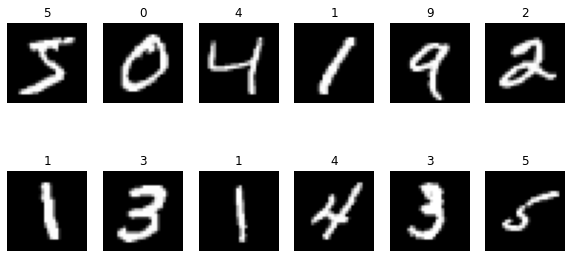

In [20]:
# test plotting function
plot_num=12
images_to_plot = np.array( [ mnist_trainset[i][0].view(28,28).numpy() 
                            for i in range(0,plot_num)])
titles = [ mnist_trainset[i][1] for i in range(0,plot_num) ] 
plot_images( images_to_plot, titles)

## Generator and discriminator models

* We now define our generator and discriminator models. Both are FC networks: MNIST is simple enough to do without (de-)convolutions. But feel free to extend the code and try different architectures. See [this tutorial](https://pytorch.org/tutorials/beginner/dcgan_faces_tutorial.html) on deep convolutional GANs for more advanced architecture examples. Note the use of Leaky RELUs for activation functions.
* Generator and discriminator can be used in both conditional and unconditional modes.
* Input of generator is noise vector of size 100 + optional class embedding of size 10 (better than simple one-hot encoding of MNIST label). Output of generator is squashed in $[-1,1]$ using _tanh_ (compatibly with above transform). Note that linear layers are defined in order to "upsample" the resolution
* Input of discriminator is an MNIST pic + optional class embedding of size 10. Note that here we use a sigmoid for the output (we need to return 1 probability value).

In [24]:
# (conditional) generator model
class GeneratorModel(nn.Module):
    def __init__(self, conditional=False):
        super(GeneratorModel, self).__init__()
        embedding_size = 10
        # random vector of size 100
        input_dim = 100 + (embedding_size if conditional else 0)
        output_dim = 784
        
        self.label_embedding = nn.Embedding(10, embedding_size)

        self.hidden_layer1 = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2)
        )

        self.hidden_layer2 = nn.Sequential(
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2)
        )
        self.output_layer = nn.Sequential(
            nn.Linear(512, output_dim),
            nn.Tanh()# squashes output between -1 and 1
        )
        
    def forward(self, x, labels=None):
        
        if(labels is not None):
            c = self.label_embedding(labels)
            x = torch.cat([x, c], 1)
        
        output = self.hidden_layer1(x)
        output = self.hidden_layer2(output)
        output = self.output_layer(output)
        return output.to(device)

In [23]:
# (conditional) discriminator model

class DiscriminatorModel(nn.Module):
    def __init__(self, conditional=False):
        super(DiscriminatorModel, self).__init__()
        embedding_size = 10
        input_dim = 784 + (embedding_size if conditional else 0)

        self.label_embedding = nn.Embedding(10, embedding_size)

        self.hidden_layer1 = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3)
        )

        self.hidden_layer2 = nn.Sequential(
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3)
        )

        self.output_layer = nn.Sequential(
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x, labels=None):
        
        if(labels is not None):
            c = self.label_embedding(labels)
            x = torch.cat([x, c], 1)
            
        output = self.hidden_layer1(x)
        output = self.hidden_layer2(output)
        output = self.output_layer(output)

        return output.to(device)


In [41]:
def train(conditional,discriminator,generator,loss,data_loader,device,batch_size,n_epochs=10):

    discriminator_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002)
    generator_optimizer = optim.Adam(generator.parameters(), lr=0.0002)

    for epoch_idx in range(n_epochs):
        G_loss = []
        D_loss = []
        
        for batch_idx, minibatch in enumerate(data_loader):
            # extract MNIST pictures and corresponding true labels
            true_data = minibatch[0].view(batch_size, 784).to(device)
            digit_labels = minibatch[1].to(device) if conditional else None
            
            # generate noise vector and fake labels (if in "conditional" model)
            noise = torch.randn(batch_size,100).to(device)
            fake_labels = torch.randint(0, 10, (batch_size,)).to(device) if conditional else None
            generated_data = generator(noise, fake_labels) 


            # Update the discriminator
            ones = torch.ones(batch_size).to(device)
            zeros = torch.zeros(batch_size).to(device)

            discriminator_optimizer.zero_grad()

            # compute output and loss of D for true data
            discriminator_output_for_true_data = discriminator(true_data, digit_labels).view(batch_size)
            true_discriminator_loss = loss(discriminator_output_for_true_data, ones)
            
            # compute output and loss of D for synthetic data
            # note the "detach" operation to remove "generated data" from the computational graph 
            # (and ensure gradient) is not propagated to generator
            discriminator_output_for_generated_data = discriminator(generated_data.detach(),fake_labels).view(batch_size)
            generator_discriminator_loss = loss(discriminator_output_for_generated_data, zeros)
            
            # use average of the two losses (just to make it easier to compare with the generator-only loss later on)
            discriminator_loss = (true_discriminator_loss + generator_discriminator_loss) / 2

            discriminator_loss.backward()
            discriminator_optimizer.step()

            D_loss.append(discriminator_loss.data.item())


            # Generator

            generator_optimizer.zero_grad()
            # It's a choice to generate the data again
            generated_data = generator(noise, fake_labels) 
            discriminator_output_on_generated_data = discriminator(generated_data, fake_labels).view(batch_size)
            # note that here we must not detach the tensor, why? (figure it out on your own)
            generator_loss = loss(discriminator_output_on_generated_data, ones)
            generator_loss.backward()
            generator_optimizer.step()

            G_loss.append(generator_loss.data.item())

        print('[%d/%d]: loss_d: %.3f, loss_g: %.3f' %((epoch_idx+1), n_epochs, torch.mean(torch.FloatTensor(D_loss)), torch.mean(torch.FloatTensor(G_loss))))
            
    return (generator, discriminator, G_loss, D_loss)

In [42]:
# run loop for non-conditional case
conditional=False
discriminator = DiscriminatorModel().to(device) # non-conditional discriminator
generator = GeneratorModel().to(device) # non-conditional generator

loss = nn.BCELoss()
(generator, discriminator, G_loss, D_loss)=train(
    conditional,discriminator,generator,loss,data_loader,device,batch_size)

[0/10]: loss_d: 0.312, loss_g: 2.798
[1/10]: loss_d: 0.337, loss_g: 2.116
[2/10]: loss_d: 0.234, loss_g: 3.138
[3/10]: loss_d: 0.291, loss_g: 2.639
[4/10]: loss_d: 0.296, loss_g: 2.634
[5/10]: loss_d: 0.337, loss_g: 2.371
[6/10]: loss_d: 0.374, loss_g: 2.105
[7/10]: loss_d: 0.355, loss_g: 2.146
[8/10]: loss_d: 0.386, loss_g: 1.981
[9/10]: loss_d: 0.393, loss_g: 1.939


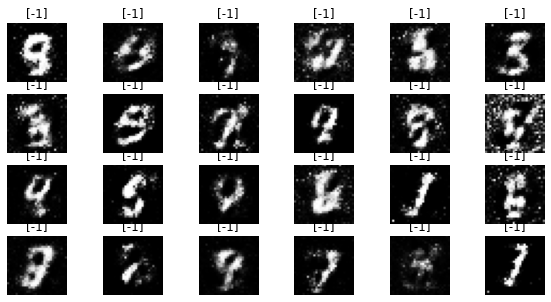

In [48]:
# generate and plot some data
gen_images_to_plot = []
num_imgs = 24
with torch.no_grad():
    noise = torch.randn(num_imgs,100).to(device)
    #fake_labels = torch.randint(0, 10, (batch_size,)).to(device)
    #generated_data = generator(noise, fake_labels).cpu().view(batch_size, 28, 28)
    generated_data = generator(noise).cpu().view(num_imgs, 28, 28)
    gen_images_to_plot = [x.detach().numpy() for x in generated_data]
    #titles = fake_labels.numpy()
    titles = np.full([len(gen_images_to_plot),1],-1) # not class conditional, so setting label to -1
    plot_images( generated_data, titles)



In [49]:
conditional=True
c_discriminator = DiscriminatorModel(conditional).to(device) # conditional discriminator
c_generator = GeneratorModel(conditional).to(device) # conditional generator

loss = nn.BCELoss()
(c_generator, c_discriminator, G_loss, D_loss)=train(
    conditional,c_discriminator,c_generator,loss,data_loader,device,batch_size)

[0/10]: loss_d: 0.368, loss_g: 2.318
[1/10]: loss_d: 0.361, loss_g: 2.082
[2/10]: loss_d: 0.263, loss_g: 2.924
[3/10]: loss_d: 0.303, loss_g: 2.691
[4/10]: loss_d: 0.279, loss_g: 2.772
[5/10]: loss_d: 0.306, loss_g: 2.645
[6/10]: loss_d: 0.331, loss_g: 2.416
[7/10]: loss_d: 0.358, loss_g: 2.149
[8/10]: loss_d: 0.386, loss_g: 1.972
[9/10]: loss_d: 0.391, loss_g: 1.928


In [60]:
# running 10 more epochs to improve generator loss a bit
(c_generator, c_discriminator, G_loss, D_loss)=train(
    conditional,c_discriminator,c_generator,loss,data_loader,device,batch_size)

[0/10]: loss_d: 0.436, loss_g: 1.783
[1/10]: loss_d: 0.413, loss_g: 1.829
[2/10]: loss_d: 0.438, loss_g: 1.685
[3/10]: loss_d: 0.436, loss_g: 1.700
[4/10]: loss_d: 0.450, loss_g: 1.646
[5/10]: loss_d: 0.462, loss_g: 1.589
[6/10]: loss_d: 0.467, loss_g: 1.539
[7/10]: loss_d: 0.468, loss_g: 1.565
[8/10]: loss_d: 0.478, loss_g: 1.511
[9/10]: loss_d: 0.488, loss_g: 1.487


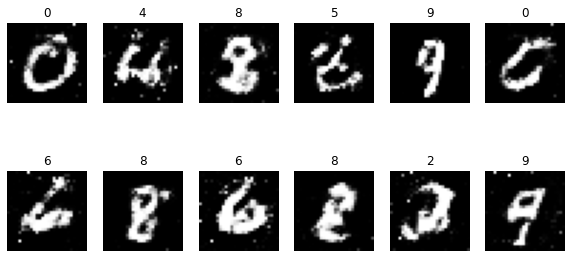

In [62]:
# generate and plot some data
gen_images_to_plot = []
num_imgs = 12
with torch.no_grad():
    noise = torch.randn(num_imgs,100).to(device)
    fake_labels = torch.randint(0, 10, (num_imgs,)).to(device)
    generated_data = c_generator(noise, fake_labels).cpu().view(num_imgs, 28, 28)
    gen_images_to_plot = [x.detach().numpy() for x in generated_data]
    titles = fake_labels.cpu().numpy()
    plot_images( generated_data, titles)

## Ideas for extension

* try different architectures, i.e., convolutions/de-convolutions
* what happens if you make it conditional on the digit being odd/even?
* try a different dataset